In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import rfft, rfftfreq
import astropy.units as u
import glob
import os
from scipy.interpolate import interp1d
import pandas as pd
from scipy.optimize import curve_fit

plt.style.use('~/light_mode.mplstyle')

Data taken on 260223 was with the 0.25mm thick mylar beamsplitter. This data mainly probed the Taurus band.

Data taken on 260224 and 260225 was with the new, 0.25mm thick kapton beamsplitter. This data probes the frequency range between Taurus and TIM, through the TIM band.

### Functions of utility

In [2]:
DATA_DIR = '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/'

In [3]:
def get_scan_properties(file):
    comps = os.path.basename(file).split('_')
    _freq = next(c for c in comps if c.endswith('GHz'))
    freq = float(_freq.removesuffix('GHz')) * u.GHz
    _vel = next(c for c in comps if c.endswith('mmps'))
    vel = float(_vel.removesuffix('mmps')) * (u.mm / u.s)
    _t_int = next(c for c in comps if c.endswith('ms'))
    t_int = float(_t_int.removeprefix('tint').removesuffix('ms')) * u.ms
    return {'freq': freq,
            'velocity_estimate': vel, 
            'inttime': t_int}

def read_enc_file(filename):
    enc_data = pd.read_csv(filename)
    enc_pos = enc_data['position_mm'].values * u.mm
    enc_ts = enc_data['timestamp'].values * u.s
    return enc_ts, enc_pos

def read_top_file(filename):
    amp_data = pd.read_csv(filename, sep='\t')
    amps = amp_data['Amplitude (via StrMod)'].values * u.nA
    amp_ts = amp_data['Timestamp (s)'].values * u.s
    return amp_ts, amps

def fourier_analysis(amp_file, enc_file):
    amp_ts, amp = read_top_file(amp_file)
    enc_ts, enc_pos = read_enc_file(enc_file)

    pos_interp = interp1d(enc_ts, enc_pos,
                      kind='linear',
                      bounds_error=False,
                      fill_value='extrapolate')
    pos_on_amp = pos_interp(amp_ts) * enc_pos.unit

    opd = 2 * pos_on_amp
    N = len(opd)
    opd_uniform = np.linspace(opd.min(), opd.max(), N)
    amp_interp = interp1d(opd, amp,
                      kind='linear',
                      bounds_error=False,
                      fill_value=0)
    
    interferogram = amp_interp(opd_uniform) * amp.unit
    interferogram -= np.mean(interferogram)

    
    delta_opd = opd_uniform[1] - opd_uniform[0]
    spec = rfft(interferogram)
    wavenumbers = rfftfreq(len(interferogram), d=delta_opd)
    freqs = wavenumbers.to(u.GHz, equivalencies=u.spectral())
    pspec = np.abs(spec)**2 

    return {
        'enc_pos': pos_on_amp,
        'opd': opd_uniform,
        'interferogram': interferogram,
        'freqs': freqs,
        'pspec': pspec
    }

def gauss(x, amp, avg, sig):
    ans = amp * np.exp(-(x-avg)**2/(2.*sig**2))
    return ans

def gaussfit(x, y, amp=1., avg=0., sig=1., return_cov=False):
    prms0 = np.array([amp, avg, sig])
    prms, prm_covariance = curve_fit(gauss, x, y, p0=prms0)
    amp, avg, sig = prms
    ans = {'amp':amp, 'avg':avg, 'sig':sig}
    if return_cov:
        return ans, prm_covariance
    else:
        return ans

# 0.25 mm Mylar

In [4]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, '260223*')))

enc_files = [f for f in all_files if f.endswith('.csv')]
top_files = [f for f in all_files if f.endswith('.txt')]

mylar_files = list(zip(top_files, enc_files))

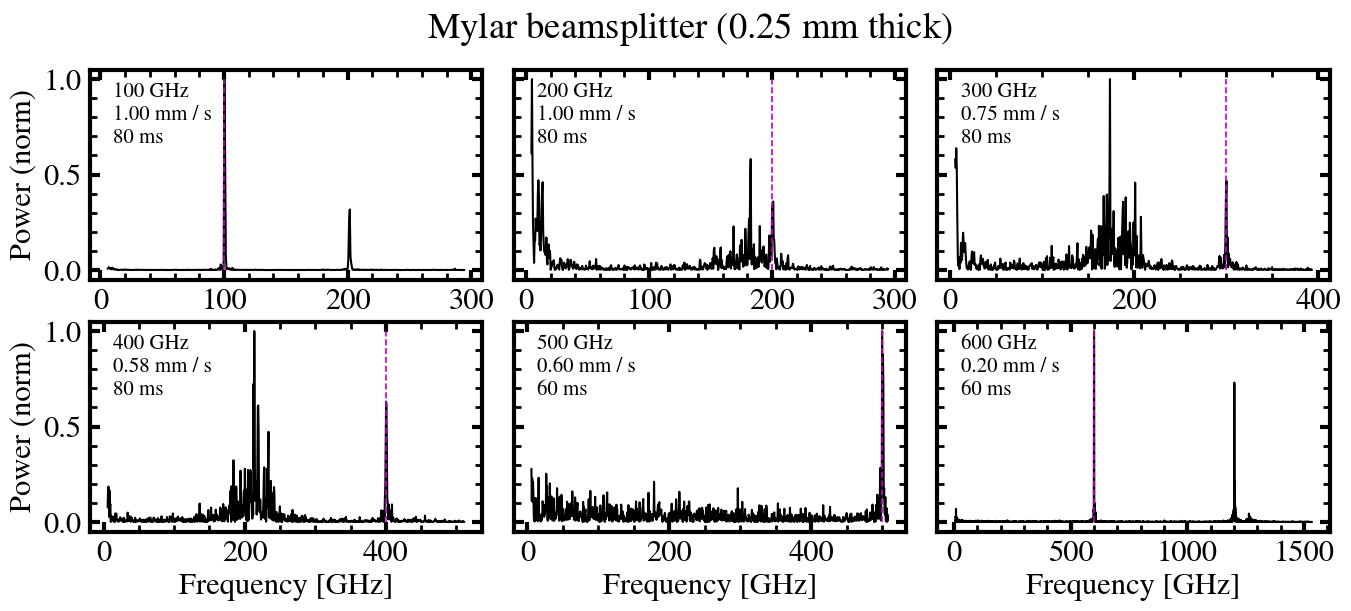

In [5]:
n = len(mylar_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(mylar_files):
    comps = get_scan_properties(top_file)
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax 

    ax = axes[i]
    ax.plot(x, y, lw=1.5, color='k')
    ax.vlines(comps['freq'].value, 0, 1, color='m', ls='dashed', lw=1.2, alpha=1)
    ax.text(0.06, 0.94, f'{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=15)
    # ax.grid(alpha=0.6)

    if i in [0, 3]:
        ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    if i in [3, 4, 5]:
        ax.set_xlabel('Frequency [GHz]')
    
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r'Mylar beamsplitter ($0.25~\rm mm$ thick)')
# plt.tight_layout()
# plt.savefig('/Users/darbymccauley/Desktop/fts_beamsplitter/toptica_fts_tests_0.25mm_mylar.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 0.25 um Kapton

In [6]:
all_files = sorted(
    glob.glob(os.path.join(DATA_DIR, '260224*')) +
    glob.glob(os.path.join(DATA_DIR, '260225*'))
)

skip = [
    '260224_toptica_900GHz_0.2mmps_tint80ms_scan.csv',
    '260225_toptica_1000GHz_0.15mmps_tint150ms_scan.csv',
    '260225_toptica_1100GHz_0.1mmps_tint300ms_scan.csv',
    '260225_toptica_1100GHz_0.1mmps_tint300ms_scan_01.csv',
    '260225_toptica_1200GHz_0.1mmps_tint200ms_scan.csv',
]

skip_stems = {os.path.splitext(name)[0] for name in skip}

kept_files = [
    f for f in all_files
    if os.path.splitext(os.path.basename(f))[0] not in skip_stems
]

enc_map = {
    os.path.splitext(os.path.basename(f))[0]: f
    for f in kept_files if f.endswith('.csv')
}
top_map = {
    os.path.splitext(os.path.basename(f))[0]: f
    for f in kept_files if f.endswith('.txt')
}

common_stems = sorted(set(top_map) & set(enc_map))
top_files = [top_map[s] for s in common_stems]
enc_files = [enc_map[s] for s in common_stems]
kapton_files = list(zip(top_files, enc_files))

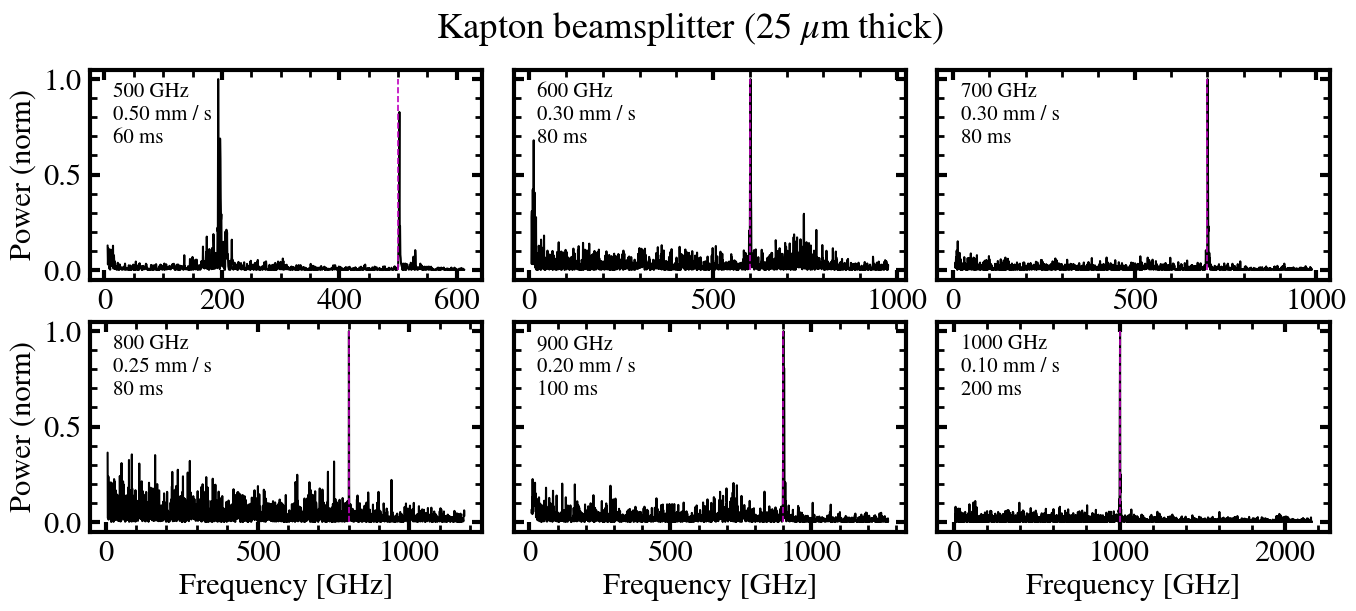

In [7]:
n = len(kapton_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(kapton_files):
    comps = get_scan_properties(top_file)
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax 

    ax = axes[i]
    ax.plot(x, y, lw=1.5, color='k')
    ax.vlines(comps['freq'].value, 0, 1, color='m', ls='dashed', lw=1.2, alpha=1)
    ax.text(0.06, 0.94, f'{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=15)
    # ax.grid(alpha=0.6)

    if i in [0, 3]:
        ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    if i in [3, 4, 5]:
        ax.set_xlabel('Frequency [GHz]')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r'Kapton beamsplitter ($25~\mu \rm m$ thick)')
# plt.tight_layout()
# plt.savefig('/Users/darbymccauley/Desktop/fts_beamsplitter/toptica_fts_tests_25um_kapton.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Broad noise features around $200~\rm GHz$

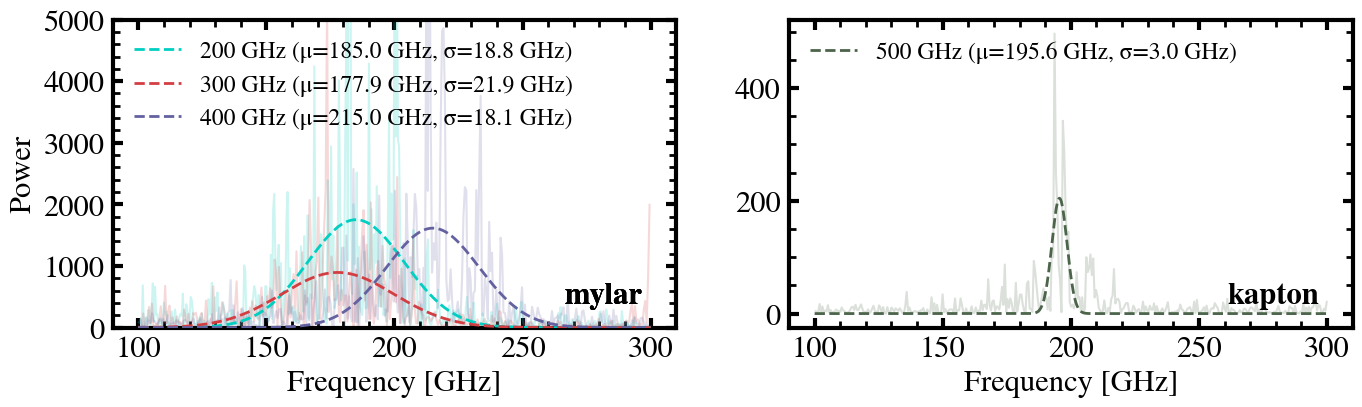

In [8]:
mylar_200_noise = mylar_files[1:4]
kapton_200_noise = [kapton_files[0]]

mylar_colors = ['#00CFC1', '#D33E43', '#6461A0']
kapton_colors = ['#4B644A']

xrange = np.linspace(100, 300, 1000)


fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for i, (top_file, enc_file) in enumerate(mylar_200_noise):
    comps = get_scan_properties(top_file)
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'].to_value(u.GHz)
    y = fa['pspec']
    freq_mask = (x > 100) & (x < 300)
    freqs = x[freq_mask]
    pspec = y[freq_mask]

    axes[0].plot(freqs, pspec, lw=1.5, alpha=0.2, color=mylar_colors[i])
    fit_pars = gaussfit(freqs, pspec, amp=np.max(pspec.value), avg=200, sig=20, return_cov=False)
    axes[0].plot(xrange, gauss(xrange, fit_pars['amp'], fit_pars['avg'], fit_pars['sig']), 
                 color=mylar_colors[i], lw=2, ls='dashed', zorder=15,
                 label=f'{comps['freq']:.0f} (μ={fit_pars['avg']:.1f} GHz, σ={fit_pars['sig']:.1f} GHz)')
    
    axes[0].legend(loc='upper left', ncol=1, frameon=False)
    axes[0].set_ylim(0, 5000)
    axes[0].text(0.94, 0.06, 'mylar', transform=axes[0].transAxes, ha='right', va='bottom', fontweight='bold')

for i, (top_file, enc_file) in enumerate(kapton_200_noise):
    comps = get_scan_properties(top_file)
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'].to_value(u.GHz)
    y = fa['pspec']
    freq_mask = (x > 100) & (x < 300)
    freqs = x[freq_mask]
    pspec = y[freq_mask]

    axes[1].plot(freqs, pspec, lw=1.5, alpha=0.2, color=kapton_colors[i])
    fit_pars = gaussfit(freqs, pspec, amp=np.max(pspec.value), avg=200, sig=20, return_cov=False)
    axes[1].plot(xrange, gauss(xrange, fit_pars['amp'], fit_pars['avg'], fit_pars['sig']), 
                 color=kapton_colors[i], lw=2, ls='dashed', zorder=15,
                 label=f'{comps['freq']:.0f} (μ={fit_pars['avg']:.1f} GHz, σ={fit_pars['sig']:.1f} GHz)')
    axes[1].legend(loc='upper left', ncol=1, frameon=False)
    axes[1].text(0.94, 0.06, 'kapton', transform=axes[1].transAxes, ha='right', va='bottom', fontweight='bold')

axes[0].set_ylabel('Power')
axes[0].set_xlabel('Frequency [GHz]')
axes[1].set_xlabel('Frequency [GHz]')
plt.show()

# Probing broad noise features ($25~\mu \rm m$ kapton beamsplitter)

All data collected on 26027

In [9]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, '260227*')))

enc_files = [f for f in all_files if f.endswith('.csv')]
top_files = [f for f in all_files if f.endswith('.txt')]

files_27 = list(zip(top_files, enc_files))

list(top_files)

['/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_100GHz_0.5mmps_tint60ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_200GHz_0.5mmps_tint60ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_300GHz_0.5mmps_tint60ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_400GHz_0.4mmps_tint30ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_400GHz_0.4mmps_tint60ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_400GHz_0.4mmps_tint80ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_400GHz_0.58mmps_tint30ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans/260227_toptica_400GHz_0.58mmps_tint80ms_scan.txt',
 '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/

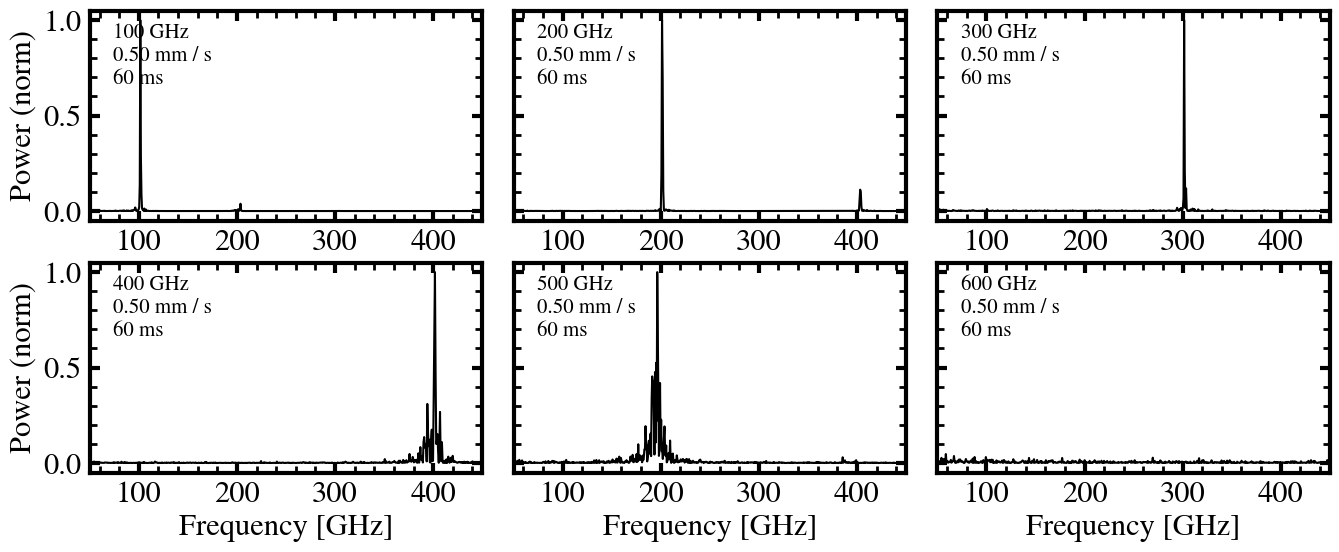

In [10]:
selected_files = []
for top_file, enc_file in files_27:
    comps = get_scan_properties(top_file)
    if (comps['velocity_estimate'].value == 0.5) and (comps['inttime'].value == 60):
        selected_files.append((top_file, enc_file))

n = len(selected_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(selected_files):
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax

    ax = axes[i]
    ax.set_xlim(50, 450)
    ax.plot(x, y, lw=1.5, color='k')

    comps = get_scan_properties(top_file)
    ax.text(0.06, 0.94, f"{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=15)

    if i in [0, 3]:
            ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    if i in [3, 4, 5]:
        ax.set_xlabel('Frequency [GHz]')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.show()

Possibly frequency dependent (shows up only in the 500 GHz injected spectra). I am able to recreate it from an earlier date, meaning it is reproducable. 

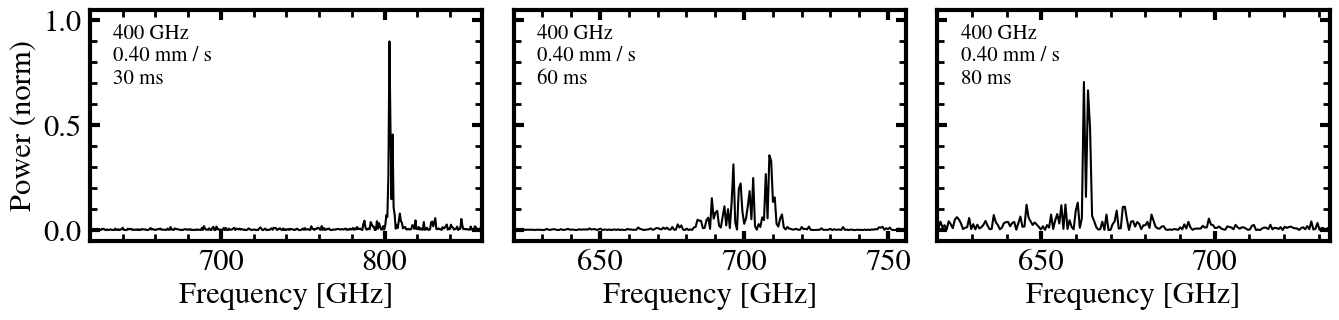

In [11]:
selected_files = []
for top_file, enc_file in files_27:
    comps = get_scan_properties(top_file)
    if comps['velocity_estimate'].value == 0.4:
        selected_files.append((top_file, enc_file))

n = len(selected_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(selected_files):
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax

    ax = axes[i]
    ax.set_xlim(620, x.max())
    ax.plot(x, y, lw=1.5, color='k')

    comps = get_scan_properties(top_file)
    ax.text(0.06, 0.94, f"{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=15)

    if i in [0]:
            ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    ax.set_xlabel('Frequency [GHz]')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.show()

Noise walks to lower frequencies as $t_\mathrm{int}$ increases. Appears change is well behaved as a function of $t_\mathrm{int}$. But gotta be a bit careful because the 30 ms peak is also at a harmonic.

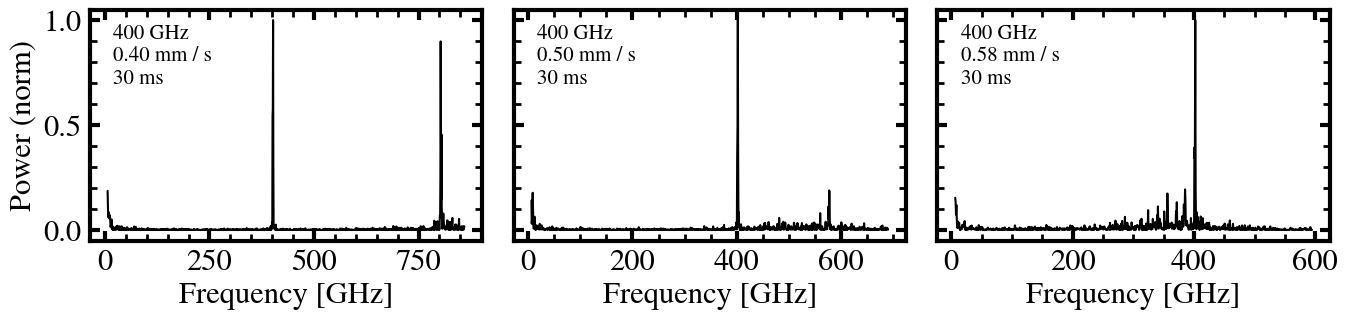

In [12]:
files_27 = sorted(
    files_27,
    key=lambda pair: get_scan_properties(pair[0])['velocity_estimate'].value
)
selected_files = []
for top_file, enc_file in files_27:
    comps = get_scan_properties(top_file)
    if (comps['freq'].value == 400) and (comps['inttime'].value == 30):
        selected_files.append((top_file, enc_file))

n = len(selected_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(selected_files):
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax

    ax = axes[i]
    # ax.set_xlim(620, x.max())
    ax.plot(x, y, lw=1.5, color='k')

    comps = get_scan_properties(top_file)
    ax.text(0.06, 0.94, f"{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=15)

    if i in [0]:
            ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    ax.set_xlabel('Frequency [GHz]')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.show()

Increasing scan velocity decreases frequency of the noise.

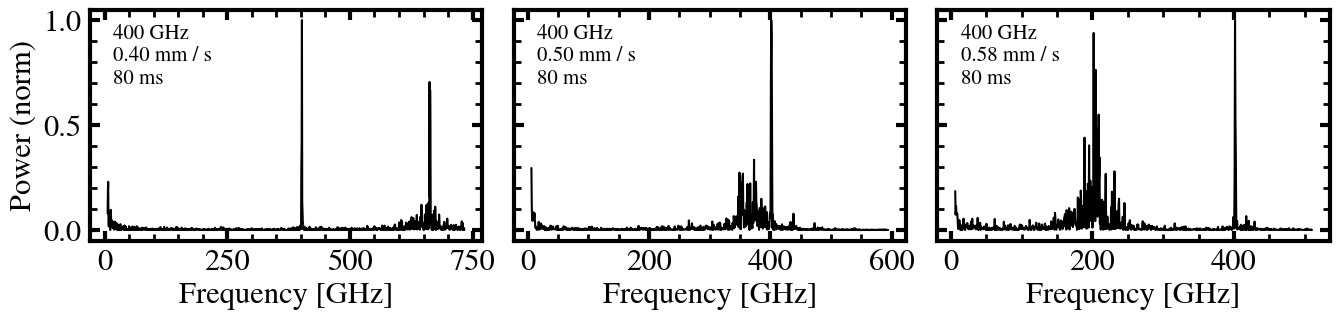

In [13]:
files_27 = sorted(
    files_27,
    key=lambda pair: get_scan_properties(pair[0])['velocity_estimate'].value
)
selected_files = []
for top_file, enc_file in files_27:
    comps = get_scan_properties(top_file)
    if (comps['freq'].value == 400) and (comps['inttime'].value == 80):
        selected_files.append((top_file, enc_file))

n = len(selected_files)
ncols = 3
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3), sharey=True)
axes = np.atleast_1d(axes).ravel()
fig.subplots_adjust(wspace=0.08)

for i, (top_file, enc_file) in enumerate(selected_files):
    fa = fourier_analysis(top_file, enc_file)
    x = fa['freqs'][10:].to_value(u.GHz)
    y = fa['pspec'][10:]
    ymax = np.max(y)
    y = y / ymax

    ax = axes[i]
    # ax.set_xlim(620, x.max())
    ax.plot(x, y, lw=1.5, color='k')

    comps = get_scan_properties(top_file)
    ax.text(0.06, 0.94, f"{comps['freq']:.0f}\n{comps['velocity_estimate']:.2f}\n{comps['inttime']:.0f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=15)

    if i in [0]:
            ax.set_ylabel(r'Power (norm)')
    else:
        ax.tick_params(axis='y', which='both', labelleft=False)
    ax.set_xlabel('Frequency [GHz]')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.show()